In [46]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import warnings

warnings.filterwarnings('ignore')
#sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#statistical libraries 
from scipy import stats
from scipy.stats import zscore, skew 

# set style for better visualizations 
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("libraries imported successfully!")


libraries imported successfully!


In [2]:
zip_path = r"C:\Users\User\Desktop\ABEOKUTA\AI_Engineer\DataAndData_analysis\DataAndData_analysis\Task_folder\pandas\exploratorytask\wine+quality (1).zip"

with zipfile.ZipFile(zip_path,'r') as zip_ref:
    zip_ref.printdir()

File Name                                             Modified             Size
winequality-red.csv                            2023-05-22 22:24:00        84199
winequality-white.csv                          2023-05-22 22:24:00       264426
winequality.names                              2023-05-22 22:24:00         3305


In [4]:
with zipfile.ZipFile(zip_path) as z:
    with z.open('winequality-white.csv') as f:
        df =pd.read_csv(f,sep=";")

### **Eda- Based data quality assessment**

In [20]:
# Create a copy for preprocessing 
df_processed = df.copy()

#1. check for missing values
print("\n1. Missing Values:")
missing_values = df_processed.isnull().sum()
if missing_values.sum() > 0:
        print(missing_values[missing_values > 0])
else:
    print("No missing values found (as expected from EDA)")


# 2. Check for duplicates
print("\n2. Duplicate Rows:")
duplicates = df_processed.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    print(f"Percentage of duplicates: {(duplicates/len(df_processed))*100:.2f}%")

# 3. Check skewness for variables identified in EDA as right-skewed
print("\n3. Skewness Analysis (EDA identified right-skewed variables):")
skewed_vars = ['residual sugar', 'total sulfur dioxide', 'chlorides']
for var in skewed_vars:
    if var in df_processed.columns:
        skewness = skew(df_processed[var])
        print(f"{var}: skewness = {skewness:.3f} ({'right-skewed' if skewness > 0.5 else 'approximately normal'})")


# 4. Check correlation with target (EDA evidence)
print("\n4. Correlation with Quality (EDA Evidence):")
correlations= df_processed.corrwith(df_processed['quality']).sort_values(key=abs,ascending=False)
print(correlations)
print("High-signal features (|correlation| > 0.2):")
high_signal = correlations[abs(correlations)>0.2].drop('quality')
print(high_signal)
for feature,corr in high_signal.items():
     print(f"  {feature}: {corr:.3f}")


print("\nLow-signal features (|correlation| < 0.1):")
low_signal = correlations[abs(correlations) < 0.1]
for feature, corr in low_signal.items():
    print(f"  {feature}: {corr:.3f}")

     


1. Missing Values:
No missing values found (as expected from EDA)

2. Duplicate Rows:
Number of duplicate rows: 937
Percentage of duplicates: 19.13%

3. Skewness Analysis (EDA identified right-skewed variables):
residual sugar: skewness = 1.077 (right-skewed)
total sulfur dioxide: skewness = 0.391 (approximately normal)
chlorides: skewness = 5.022 (right-skewed)

4. Correlation with Quality (EDA Evidence):
quality                 1.000000
alcohol                 0.435575
density                -0.307123
chlorides              -0.209934
volatile acidity       -0.194723
total sulfur dioxide   -0.174737
fixed acidity          -0.113663
pH                      0.099427
residual sugar         -0.097577
sulphates               0.053678
citric acid            -0.009209
free sulfur dioxide     0.008158
dtype: float64
High-signal features (|correlation| > 0.2):
alcohol      0.435575
density     -0.307123
chlorides   -0.209934
dtype: float64
  alcohol: 0.436
  density: -0.307
  chlorides: -0.21

### **3. Handle Duplicates**

In [21]:
# Remove duplicates if any (EDA didn't report duplicates, but let's be thorough)
if duplicates > 0:
    print(f"Removing {duplicates} duplicate rows...")
    df_processed = df_processed.drop_duplicates()
    print(f"Dataset shape after removing duplicates: {df_processed.shape}")
else:
    print("✓ No duplicates to remove (as expected from EDA)")


Removing 937 duplicate rows...
Dataset shape after removing duplicates: (3961, 12)


#### **4. Log-Transform Skewed Variables (EDA Recommendation)**

Based on EDA findings, transform the right-skewed variables identified

In [22]:
# Log-transform skewed variables as recommended by EDA
print("=== LOG-TRANSFORMING SKEWED VARIABLES ===")
print("EDA identified these variables as right-skewed and recommended log transformation:")
# Variables to log-transform based on EDA findings

skewed_vars = ['residual sugar', 'total sulfur dioxide', 'chlorides']

for var in skewed_vars:
    if var in df_processed.columns:
    #check if variable has zero or negative values 
        min_val = df_processed[var].min()
        if min_val <= 0:
            #use log1p for variables with zeros
            df_processed[f'{var}_log']=np.log1p(df_processed[var])
        else:
            # Use log for positive values only
            df_processed[f'{var}_log'] = np.log(df_processed[var])
            print(f"✓ {var}: Applied log transformation")
        
        # Check skewness before and after
        original_skew = skew(df_processed[var])
        transformed_skew = skew(df_processed[f'{var}_log'])
        print(f"  Original skewness: {original_skew:.3f} → Transformed skewness: {transformed_skew:.3f}")


print(f"\nDataset shape after log transformation: {df_processed.shape}")
print("New log-transformed columns:", [col for col in df_processed.columns if '_log' in col])



=== LOG-TRANSFORMING SKEWED VARIABLES ===
EDA identified these variables as right-skewed and recommended log transformation:
✓ residual sugar: Applied log transformation
  Original skewness: 1.333 → Transformed skewness: -0.058
✓ total sulfur dioxide: Applied log transformation
  Original skewness: 0.457 → Transformed skewness: -0.942
✓ chlorides: Applied log transformation
  Original skewness: 4.967 → Transformed skewness: 1.221

Dataset shape after log transformation: (3961, 15)
New log-transformed columns: ['residual sugar_log', 'total sulfur dioxide_log', 'chlorides_log']


#### **5. Outlier Treatment (EDA Recommendation)**
Based on EDA findings, handle outliers using IQR-capping metho

In [25]:
# Outlier treatment based on EDA recommendations
print("=== OUTLIER TREATMENT (IQR-CAPPING METHOD) ===")
print("EDA recommended IQR-capping for extreme acidity/sulphates to preserve data points")

# Define numerical columns (excluding target)
numerical_cols = df_processed.select_dtypes(include='number').columns.to_list()
if 'quality' in numerical_cols:
    numerical_cols.remove('quality')
print(f"Treating outliers in {len(numerical_cols)} numerical features...")


# Apply IQR-capping method
outliers_capped = 0
for col in numerical_cols:
    Q1 = df_processed[col].quantile(0.25)
    Q3 = df_processed[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count outliers before capping
    outliers_before = ((df_processed[col] < lower_bound) | (df_processed[col] > upper_bound)).sum()
    
    if outliers_before > 0:
        # Cap outliers
        df_processed[col] = np.where(df_processed[col] < lower_bound, lower_bound, df_processed[col])
        df_processed[col] = np.where(df_processed[col] > upper_bound, upper_bound, df_processed[col])
        outliers_capped += outliers_before
        print(f"✓ {col}: Capped {outliers_before} outliers")

print(f"\nTotal outliers capped: {outliers_capped}")
print(f"Dataset shape after outlier treatment: {df_processed.shape}")


=== OUTLIER TREATMENT (IQR-CAPPING METHOD) ===
EDA recommended IQR-capping for extreme acidity/sulphates to preserve data points
Treating outliers in 14 numerical features...
✓ fixed acidity: Capped 106 outliers
✓ volatile acidity: Capped 133 outliers
✓ citric acid: Capped 223 outliers
✓ residual sugar: Capped 16 outliers
✓ chlorides: Capped 178 outliers
✓ free sulfur dioxide: Capped 44 outliers
✓ total sulfur dioxide: Capped 14 outliers
✓ density: Capped 6 outliers
✓ pH: Capped 46 outliers
✓ sulphates: Capped 96 outliers
✓ total sulfur dioxide_log: Capped 51 outliers
✓ chlorides_log: Capped 180 outliers

Total outliers capped: 1093
Dataset shape after outlier treatment: (3961, 15)


#### **6. Feature Engineering**

Implement the specific feature engineering recommendations from the EDA report

In [27]:
print("FEATURE ENGINEERING BASED ON EDA RECOMMENDATIONS")

# 1. Acidity ratio: fixed_to_volatile = fixed_acidity / volatile_acidity
# EDA rationale: Quality improves when stable acids (fixed) dominate over volatile (harsh) acids
print("1. Creating acidity ratio features...")
eps = 1e-6  # Small constant to avoid divide-by-zero

df_processed['FA_to_VA_ratio'] = df_processed['fixed acidity'] / (df_processed['volatile acidity'] + eps)
print("- FA_to_VA_ratio: fixed_acidity / volatile_acidity")

# 2. Citric balance: citric_over_total_acid = citric_acid / (fixed_acidity + volatile_acidity + eps)
# EDA rationale: Citric acid adds freshness, normalize by total acid captures relative freshness
df_processed['citric_over_total_acid'] = df_processed['citric acid'] / (df_processed['fixed acidity'] + df_processed['volatile acidity'] + eps)
print("- citric_over_total_acid: citric_acid / (fixed_acidity + volatile_acidity)")

# 3. Alcohol–Acidity interaction: alcohol / volatile_acidity
# EDA rationale: High alcohol only signals high quality when volatile acidity is low
df_processed['alcohol_acid_interaction'] = df_processed['alcohol'] / (df_processed['volatile acidity'] + eps)
print("- alcohol_acid_interaction: alcohol / volatile_acidity")

# 4. Fermentation efficiency: alcohol_density_ratio = alcohol / density
# EDA rationale: Density decreases while alcohol increases with quality - captures fermentation completeness
df_processed['alcohol_density_ratio'] = df_processed['alcohol'] / (df_processed['density'] + eps)
print("- alcohol_density_ratio: alcohol / density")

# 5. Sulphate–citric interaction: sulphates * citric_acid
# EDA rationale: Sulphates and citric acid jointly correlate with perceived freshness and preservation
df_processed['sulphate_citric_interaction'] = df_processed['sulphates'] * df_processed['citric acid']
print("- sulphate_citric_interaction: sulphates * citric_acid")

# 6. Total acidity (sum of all acidity measures)
df_processed['total_acidity'] = df_processed['fixed acidity'] + df_processed['volatile acidity'] + df_processed['citric acid']
print("- total_acidity: sum of all acidity measures")

# 7. pH-acidity balance (EDA showed pH and acidity are chemically related)
df_processed['ph_acidity_balance'] = df_processed['pH'] * df_processed['total_acidity']
print("- ph_acidity_balance: pH * total_acidity")

print(f"\nDataset shape after feature engineering: {df_processed.shape}")
print(f"New engineered features: {[col for col in df_processed.columns if col not in df.columns]}")


FEATURE ENGINEERING BASED ON EDA RECOMMENDATIONS
1. Creating acidity ratio features...
- FA_to_VA_ratio: fixed_acidity / volatile_acidity
- citric_over_total_acid: citric_acid / (fixed_acidity + volatile_acidity)
- alcohol_acid_interaction: alcohol / volatile_acidity
- alcohol_density_ratio: alcohol / density
- sulphate_citric_interaction: sulphates * citric_acid
- total_acidity: sum of all acidity measures
- ph_acidity_balance: pH * total_acidity

Dataset shape after feature engineering: (3961, 22)
New engineered features: ['residual sugar_log', 'total sulfur dioxide_log', 'chlorides_log', 'FA_to_VA_ratio', 'citric_over_total_acid', 'alcohol_acid_interaction', 'alcohol_density_ratio', 'sulphate_citric_interaction', 'total_acidity', 'ph_acidity_balance']


#### **7. Feature Selection**

Based on EDA correlation analysis, select high-signal features and evaluate low-signal ones

In [43]:
# Feature selection based on EDA correlation evidence
print("=== FEATURE SELECTION BASED ON EDA CORRELATION EVIDENCE ===")

# Separate features and target
X= df_processed.drop('quality', axis=1)
Y = df_processed['quality']
print(f"Total features available: {X.shape[1]}")

# EDA-identified high-signal features (|correlation| > 0.2)
high_signal_features = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'density', 'chlorides']
print(f"\nEDA-identified high-signal features: {high_signal_features}")

# EDA-identified low-signal features (|correlation| < 0.1) 
low_signal_features = ['residual sugar', 'free sulfur dioxide']
print(f"EDA-identified low-signal features: {low_signal_features}")

# Check which features are actually available
available_high_signal = [f for f in high_signal_features if f in X.columns]
available_low_signal = [f for f in low_signal_features if f in X.columns]

print(f"\nAvailable high-signal features: {available_high_signal} {len(available_high_signal)} out of {len(high_signal_features)}")
print(f"Available low-signal features: {available_low_signal} {len(available_low_signal)} out of {len(low_signal_features)}")

# Create feature sets for evaluation
print("\n=== FEATURE SETS FOR EVALUATION ===")

# Set 1: All original features (excluding low-signal)
features_exclude_low_signal = [col for col in X.columns if col not in low_signal_features]
print(f"Set 1 - Exclude low-signal features: {len(features_exclude_low_signal)} features")
# Set 2: High-signal + engineered features
high_signal_plus_engineered = available_high_signal + [col for col in X.columns if any(keyword in col.lower() for keyword in ['ratio', 'interaction', 'balance', 'total', 'log'])]
print(f"Set 2 - High-signal + engineered: {len(high_signal_plus_engineered)} features")


# Set 3: All features (for comparison)
all_features = list(X.columns)
print(f"Set 3 - All features: {len(all_features)} features")


# Let's use Set 2 (high-signal + engineered) as recommended by EDA
selected_features = high_signal_plus_engineered
print(f"\n✓ Selected feature set: {len(selected_features)} features")
print("Selected features:", selected_features)



=== FEATURE SELECTION BASED ON EDA CORRELATION EVIDENCE ===
Total features available: 21

EDA-identified high-signal features: ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'density', 'chlorides']
EDA-identified low-signal features: ['residual sugar', 'free sulfur dioxide']

Available high-signal features: ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'density', 'chlorides'] 6 out of 6
Available low-signal features: ['residual sugar', 'free sulfur dioxide'] 2 out of 2

=== FEATURE SETS FOR EVALUATION ===
Set 1 - Exclude low-signal features: 19 features
Set 2 - High-signal + engineered: 17 features
Set 3 - All features: 21 features

✓ Selected feature set: 17 features
Selected features: ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'density', 'chlorides', 'total sulfur dioxide', 'residual sugar_log', 'total sulfur dioxide_log', 'chlorides_log', 'FA_to_VA_ratio', 'citric_over_total_acid', 'alcohol_acid_interaction', 'alcohol_density_ratio', 'sulp

#### **8. Data Splitting (Stratified)**


Based on EDA findings about class imbalance, use stratified splitting


In [45]:
# Stratified data splitting based on EDA findings about class imbalance
print("=== STRATIFIED DATA SPLITTING ===")
print("EDA identified class imbalance - using stratified splitting to preserve class distribution")

# Select the chosen features
X_selected = X[selected_features]
print(f"Selected features shape: {X_selected.shape}")

# First split: 80% train+val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X_selected, Y, test_size=0.2, random_state=42, stratify=Y
)

# Second split: 75% train, 25% validation (of the 80%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"\nData split results:")
print(f"Training set: {X_train.shape} ({(X_train.shape[0]/len(X_selected))*100:.1f}%)")
print(f"Validation set: {X_val.shape} ({(X_val.shape[0]/len(X_selected))*100:.1f}%)")
print(f"Test set: {X_test.shape} ({(X_test.shape[0]/len(X_selected))*100:.1f}%)")

# Check class distribution in each set (should be similar due to stratification)
print(f"\nClass distribution verification:")
print("Training set quality distribution:")
print(y_train.value_counts().sort_index())
print("\nValidation set quality distribution:")
print(y_val.value_counts().sort_index())
print("\nTest set quality distribution:")
print(y_test.value_counts().sort_index())


=== STRATIFIED DATA SPLITTING ===
EDA identified class imbalance - using stratified splitting to preserve class distribution
Selected features shape: (3961, 17)

Data split results:
Training set: (2376, 17) (60.0%)
Validation set: (792, 17) (20.0%)
Test set: (793, 17) (20.0%)

Class distribution verification:
Training set quality distribution:
quality
3      12
4      91
5     705
6    1073
7     413
8      79
9       3
Name: count, dtype: int64

Validation set quality distribution:
quality
3      4
4     31
5    235
6    357
7    138
8     26
9      1
Name: count, dtype: int64

Test set quality distribution:
quality
3      4
4     31
5    235
6    358
7    138
8     26
9      1
Name: count, dtype: int64


In [50]:
# Apply StandardScaler as recommended by EDA
print("=== FEATURE SCALING (STANDARD SCALER) ===")
print("EDA recommended StandardScaler for distance-based models")

# Fit scaler on training data only (to avoid data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# Transform validation and test sets
X_val_scaled = scaler.transform(X_val)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns)

X_test_scaled = scaler.transform(X_test)

X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("✓ Scaling applied successfully!")
print(f"Training set scaled - Mean: {X_train_scaled.mean().mean():.4f}, Std: {X_train_scaled.std().mean():.4f}")
print(f"Validation set scaled - Mean: {X_val_scaled.mean().mean():.4f}, Std: {X_val_scaled.std().mean():.4f}")
print(f"Test set scaled - Mean: {X_test_scaled.mean().mean():.4f}, Std: {X_test_scaled.std().mean():.4f}")

# Verify scaling worked correctly
print(f"\nScaling verification:")
print(f"Training set - Mean ≈ 0: {abs(X_train_scaled.mean().mean()) < 0.01}")
print(f"Training set - Std ≈ 1: {abs(X_train_scaled.std().mean() - 1) < 0.01}")


=== FEATURE SCALING (STANDARD SCALER) ===
EDA recommended StandardScaler for distance-based models
✓ Scaling applied successfully!
Training set scaled - Mean: 0.0000, Std: 1.0002
Validation set scaled - Mean: -0.0066, Std: 1.0214
Test set scaled - Mean: -0.0089, Std: 1.0113

Scaling verification:
Training set - Mean ≈ 0: True
Training set - Std ≈ 1: True


#### **10. Feature Importance Analysis**

Analyze the importance of engineered features based on EDA recommendations.

=== FEATURE IMPORTANCE ANALYSIS ===
Top 10 features by correlation with quality:
 1. total_acidity: 0.050
 2. sulphates: 0.043
 3. ph_acidity_balance: 0.028
 4. total sulfur dioxide_log: 0.025
 5. total sulfur dioxide: 0.024
 6. alcohol: 0.023
 7. alcohol_density_ratio: 0.023
 8. chlorides: 0.013
 9. volatile acidity: 0.011
10. density: 0.011

Engineered features in top 10: ['total sulfur dioxide', 'total sulfur dioxide_log', 'alcohol_density_ratio', 'total_acidity', 'ph_acidity_balance']


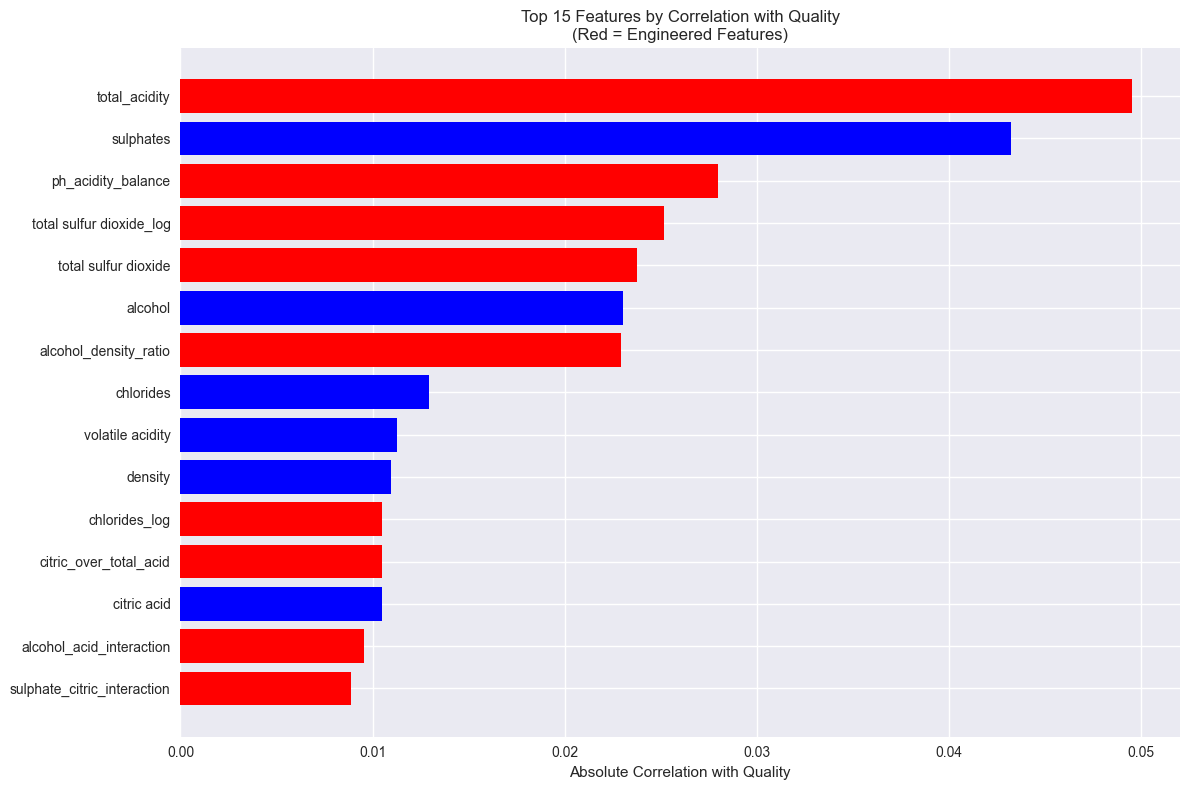

In [59]:
# Feature importance analysis to validate EDA-based engineering
print("=== FEATURE IMPORTANCE ANALYSIS ===")

# Calculate correlation with target for all features
feature_correlations = X_train_scaled.corrwith(y_train).abs().sort_values(ascending=False)

print("Top 10 features by correlation with quality:")
for i, (feature, corr) in enumerate(feature_correlations.head(10).items(), 1):
    print(f"{i:2d}. {feature}: {corr:.3f}")
# Check if engineered features are among top features
engineered_features = [col for col in X_train_scaled.columns if any(keyword in col.lower() for keyword in ['ratio', 'interaction', 'balance', 'total', 'log'])]
print(f"\nEngineered features in top 10: {[f for f in engineered_features if f in feature_correlations.head(10).index]}")

# Visualize feature importance
plt.figure(figsize=(12, 8))
top_features = feature_correlations.head(15)
colors = ['red' if any(keyword in f.lower() for keyword in ['ratio', 'interaction', 'balance', 'total', 'log']) else 'blue' for f in top_features.index]

plt.barh(range(len(top_features)), top_features.values, color=colors)
plt.yticks(range(len(top_features)), top_features.index)
plt.xlabel('Absolute Correlation with Quality')
plt.title('Top 15 Features by Correlation with Quality\n(Red = Engineered Features)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
